# Pertemuan 4 — Statistika Dasar & Analisis Data

**Mata Kuliah:** Pengantar Data Science (Kode: 200302305)  
**Program Studi:** PJJ Informatika  
**Semester:** 4  
**Dosen:** Syahid Abdullah, S.Si, M.Kom

---

**Nama :** Junior Dany Wibisono  
**NIM  :** 250401020098  
**Kelas :** IF401  
**Angkatan:** 2025  
**Tanggal:** 10 Mei 2026

---

## Tujuan Notebook
Notebook ini merupakan aktivitas hands-on Pertemuan 4 — eksplorasi statistik dataset Iris dalam 6 langkah sistematis:
1. Load & Inspect Dataset
2. Statistik Deskriptif Lengkap (mean, median, std, skewness, kurtosis)
3. Analisis Distribusi (Histogram + KDE)
4. Boxplot & Violin Plot per Spesies
5. Matriks Korelasi Pearson
6. Scatter Plot & Heatmap Korelasi

## Persiapan — Import Library

Library yang digunakan:
- **pandas** & **numpy** — manipulasi data
- **matplotlib** & **seaborn** — visualisasi
- **scipy.stats** — uji statistik (skewness test, Pearson, Spearman)

In [1]:
# Import semua library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi tampilan
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

print('Semua library berhasil diimpor!')
print(f'Pandas  : {pd.__version__}')
print(f'NumPy   : {np.__version__}')
print(f'Seaborn : {sns.__version__}')

Semua library berhasil diimpor!
Pandas  : 2.2.2
NumPy   : 2.0.2
Seaborn : 0.13.2


---
## Langkah 1 — Load & Inspect Dataset

**Dataset Iris** adalah dataset klasik dalam machine learning, terdiri dari 150 baris dan 5 kolom:

| Kolom | Tipe | Deskripsi |
|-------|------|-----------|
| `sepal_length` | float64 | Panjang kelopak (cm) |
| `sepal_width`  | float64 | Lebar kelopak (cm) |
| `petal_length` | float64 | Panjang mahkota (cm) |
| `petal_width`  | float64 | Lebar mahkota (cm) |
| `species`      | object  | Spesies: setosa / versicolor / virginica |

Dataset dimuat langsung dari Seaborn menggunakan `sns.load_dataset('iris')`.

In [2]:
# Langkah 1a: Muat dataset Iris
df = sns.load_dataset('iris')

print('=== INFORMASI DATASET IRIS ===')
print(f'Shape  : {df.shape}  ({df.shape[0]} baris × {df.shape[1]} kolom)')
print()
print('Tipe data:')
print(df.dtypes)
print()
print(f'Missing values: {df.isnull().sum().sum()}')

=== INFORMASI DATASET IRIS ===
Shape  : (150, 5)  (150 baris × 5 kolom)

Tipe data:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Missing values: 0


In [3]:
# Langkah 1b: Lima baris pertama
print('=== LIMA BARIS PERTAMA ===')
df.head()

=== LIMA BARIS PERTAMA ===


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
# Langkah 1c: Ringkasan statistik dengan .describe()
print('=== RINGKASAN STATISTIK (.describe()) ===')
df.describe().round(3)

=== RINGKASAN STATISTIK (.describe()) ===


,sepal_length,sepal_width,petal_length,petal_width
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


In [5]:
# Langkah 1d: Distribusi spesies
print('=== DISTRIBUSI SPESIES ===')
print(df['species'].value_counts())
print()
print('Dataset seimbang (balanced): setiap spesies memiliki 50 observasi.')

=== DISTRIBUSI SPESIES ===
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Dataset seimbang (balanced): setiap spesies memiliki 50 observasi.


---
## Langkah 2 — Statistik Deskriptif Lengkap

Menghitung **mean, median, std, varians, skewness, dan kurtosis** untuk setiap kolom numerik.

**Panduan interpretasi skewness:**
- `−0.5 hingga 0.5` → Simetris / normal
- `0.5 hingga 1` → Miring kanan moderat
- `> 1` → Miring kanan sangat kuat

**Panduan interpretasi kurtosis (excess):**
- `≈ 0` → Distribusi normal (mesokurtic)
- `> 0` → Leptokurtic (ekor tebal, banyak outlier)
- `< 0` → Platykurtic (ekor tipis, distribusi datar)

In [6]:
# Langkah 2a: Statistik per kolom numerik
numerik_cols = df.select_dtypes(include='number').columns

print('=== STATISTIK DESKRIPTIF LENGKAP ===')
for col_name in numerik_cols:
    col = df[col_name]
    print(f'\n--- {col_name} ---')
    print(f'  Mean      : {col.mean():.4f}')
    print(f'  Median    : {col.median():.4f}')
    print(f'  Modus     : {col.mode()[0]:.4f}')
    print(f'  Std Dev   : {col.std():.4f}')
    print(f'  Varians   : {col.var():.4f}')
    print(f'  Min       : {col.min():.4f}')
    print(f'  Max       : {col.max():.4f}')
    print(f'  Range     : {col.max()-col.min():.4f}')
    print(f'  Skewness  : {col.skew():.4f}')
    print(f'  Kurtosis  : {col.kurt():.4f}')

=== STATISTIK DESKRIPTIF LENGKAP ===

--- sepal_length ---
  Mean      : 5.8433
  Median    : 5.8000
  Modus     : 5.0000
  Std Dev   : 0.8281
  Varians   : 0.6857
  Min       : 4.3000
  Max       : 7.9000
  Range     : 3.6000
  Skewness  : 0.3149
  Kurtosis  : -0.5521

--- sepal_width ---
  Mean      : 3.0573
  Median    : 3.0000
  Modus     : 3.0000
  Std Dev   : 0.4359
  Varians   : 0.1900
  Min       : 2.0000
  Max       : 4.4000
  Range     : 2.4000
  Skewness  : 0.3190
  Kurtosis  : 0.2282

--- petal_length ---
  Mean      : 3.7580
  Median    : 4.3500
  Modus     : 1.4000
  Std Dev   : 1.7653
  Varians   : 3.1163
  Min       : 1.0000
  Max       : 6.9000
  Range     : 5.9000
  Skewness  : -0.2749
  Kurtosis  : -1.4021

--- petal_width ---
  Mean      : 1.1993
  Median    : 1.3000
  Modus     : 0.2000
  Std Dev   : 0.7622
  Varians   : 0.5810
  Min       : 0.1000
  Max       : 2.5000
  Range     : 2.4000
  Skewness  : -0.1030
  Kurtosis  : -1.3406


In [7]:
# Langkah 2b: Kuartil dan IQR
print('=== KUARTIL, PERSENTIL & IQR ===')
for col_name in numerik_cols:
    col = df[col_name]
    Q1  = col.quantile(0.25)
    Q2  = col.quantile(0.50)
    Q3  = col.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = col[(col < lower) | (col > upper)]
    print(f'{col_name:15s}: Q1={Q1:.2f}, Q2={Q2:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}, '
          f'Outlier={len(outliers)}')

=== KUARTIL, PERSENTIL & IQR ===
sepal_length   : Q1=5.10, Q2=5.80, Q3=6.40, IQR=1.30, Outlier=0
sepal_width    : Q1=2.80, Q2=3.00, Q3=3.30, IQR=0.50, Outlier=4
petal_length   : Q1=1.60, Q2=4.35, Q3=5.10, IQR=3.50, Outlier=0
petal_width    : Q1=0.30, Q2=1.30, Q3=1.80, IQR=1.50, Outlier=0


In [8]:
# Langkah 2c: Tabel ringkasan skewness dan interpretasi
print('=== INTERPRETASI SKEWNESS ===')
for col_name in numerik_cols:
    skew = df[col_name].skew()
    if abs(skew) < 0.5:
        interpretasi = 'Simetris / Normal'
    elif 0.5 <= skew < 1:
        interpretasi = 'Miring kanan moderat'
    elif skew >= 1:
        interpretasi = 'Miring kanan sangat kuat'
    elif -1 < skew <= -0.5:
        interpretasi = 'Miring kiri moderat'
    else:
        interpretasi = 'Miring kiri sangat kuat'
    print(f'{col_name:15s}: skewness={skew:+.3f} → {interpretasi}')

=== INTERPRETASI SKEWNESS ===
sepal_length   : skewness=+0.315 → Simetris / Normal
sepal_width    : skewness=+0.319 → Simetris / Normal
petal_length   : skewness=-0.275 → Simetris / Normal
petal_width    : skewness=-0.103 → Simetris / Normal


---
## Langkah 3 — Analisis Distribusi (Histogram + KDE)

**Histogram** membagi rentang data ke dalam bin dan menghitung frekuensi, menampilkan bentuk distribusi secara langsung.

**KDE (Kernel Density Estimation)** adalah versi halus histogram yang mengestimasi fungsi densitas probabilitas — lebih mudah dibaca untuk perbandingan antar kelompok.

Garis merah = Mean | Garis oranye = Median

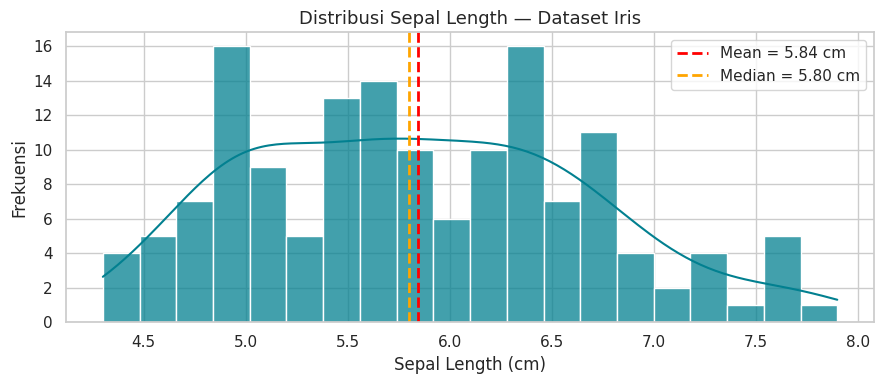

Skewness sepal_length = 0.315
Interpretasi: distribusi simetris / mendekati normal


In [9]:
# Langkah 3a: Histogram + KDE untuk sepal_length (analisis utama)
fig, ax = plt.subplots(figsize=(9, 4))

sns.histplot(df['sepal_length'], kde=True, color='#028090',
             bins=20, ax=ax, alpha=0.75)

mean_val   = df['sepal_length'].mean()
median_val = df['sepal_length'].median()

ax.axvline(mean_val,   color='red',    linestyle='--', lw=2,
           label=f'Mean = {mean_val:.2f} cm')
ax.axvline(median_val, color='orange', linestyle='--', lw=2,
           label=f'Median = {median_val:.2f} cm')

ax.set_title('Distribusi Sepal Length — Dataset Iris', fontsize=13)
ax.set_xlabel('Sepal Length (cm)')
ax.set_ylabel('Frekuensi')
ax.legend()
plt.tight_layout()
plt.savefig('hist_sepal_length.png', dpi=150)
plt.show()

skew = df['sepal_length'].skew()
print(f'Skewness sepal_length = {skew:.3f}')
print(f'Interpretasi: distribusi {"simetris / mendekati normal" if abs(skew)<0.5 else "miring"}')

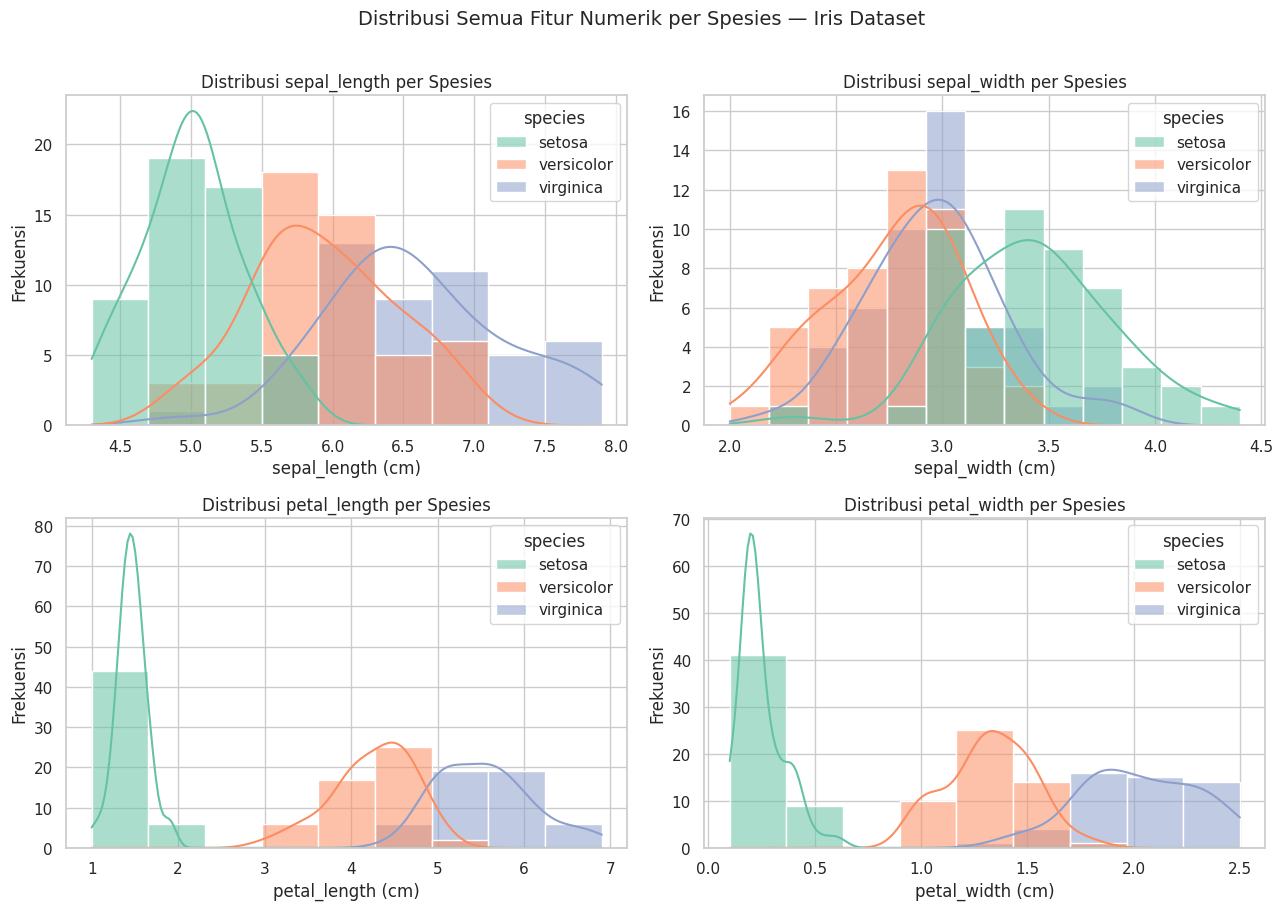

In [10]:
# Langkah 3b: Histogram + KDE semua kolom numerik per spesies
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, col_name in enumerate(numerik_cols):
    sns.histplot(data=df, x=col_name, hue='species',
                 kde=True, palette='Set2', alpha=0.55,
                 ax=axes[i])
    axes[i].set_title(f'Distribusi {col_name} per Spesies')
    axes[i].set_xlabel(f'{col_name} (cm)')
    axes[i].set_ylabel('Frekuensi')

plt.suptitle('Distribusi Semua Fitur Numerik per Spesies — Iris Dataset',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('hist_all_features.png', dpi=150)
plt.show()

**Narasi Interpretasi Langkah 3:**

- `sepal_length`: distribusi mendekati normal (simetris), dengan mean ≈ median. Terdapat sedikit tumpang tindih antar spesies, mengindikasikan perbedaan yang tidak terlalu tajam.
- `sepal_width`: distribusi paling simetris di antara keempat fitur. Setosa memiliki sepal_width tertinggi.
- `petal_length` & `petal_width`: distribusi bimodal yang jelas — Setosa sangat terpisah dari Versicolor dan Virginica, menjadikan kedua fitur ini sangat diskriminatif untuk klasifikasi spesies.

---
## Langkah 4 — Boxplot & Violin Plot per Spesies

**Boxplot** merepresentasikan lima statistik ringkasan:
- Minimum (non-outlier), Q1, Median, Q3, Maksimum (non-outlier)
- Titik di luar whisker = outlier potensial

**Violin Plot** menggabungkan boxplot dengan KDE, menampilkan bentuk distribusi penuh — lebih informatif untuk distribusi multimodal.

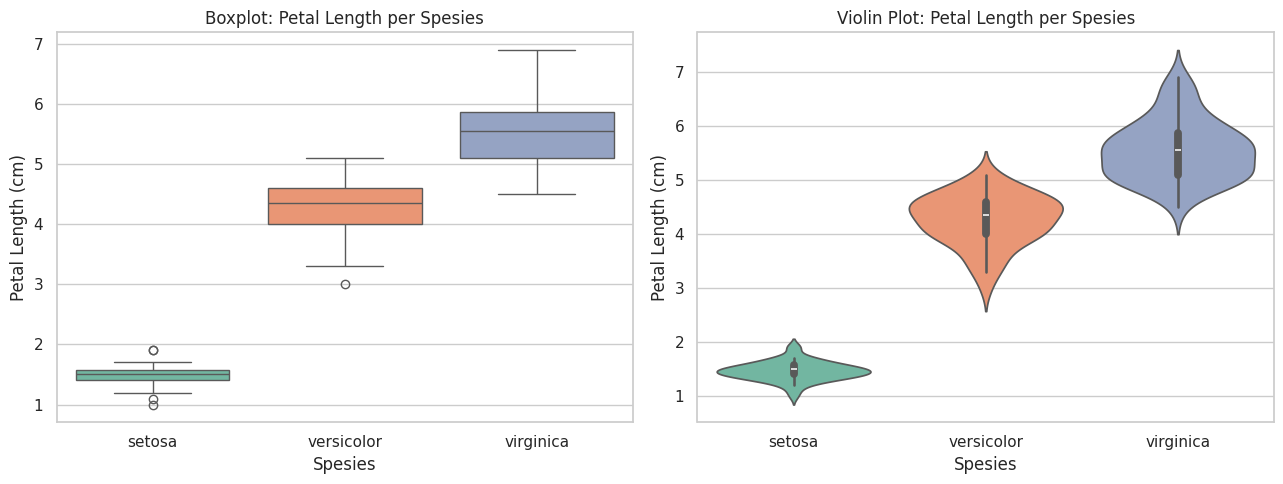

In [11]:
# Langkah 4a: Boxplot petal_length per spesies
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
sns.boxplot(data=df, x='species', y='petal_length',
            palette='Set2', ax=axes[0])
axes[0].set_title('Boxplot: Petal Length per Spesies', fontsize=12)
axes[0].set_xlabel('Spesies')
axes[0].set_ylabel('Petal Length (cm)')

# Violin Plot
sns.violinplot(data=df, x='species', y='petal_length',
               palette='Set2', inner='box', ax=axes[1])
axes[1].set_title('Violin Plot: Petal Length per Spesies', fontsize=12)
axes[1].set_xlabel('Spesies')
axes[1].set_ylabel('Petal Length (cm)')

plt.tight_layout()
plt.savefig('boxplot_petal_length.png', dpi=150)
plt.show()

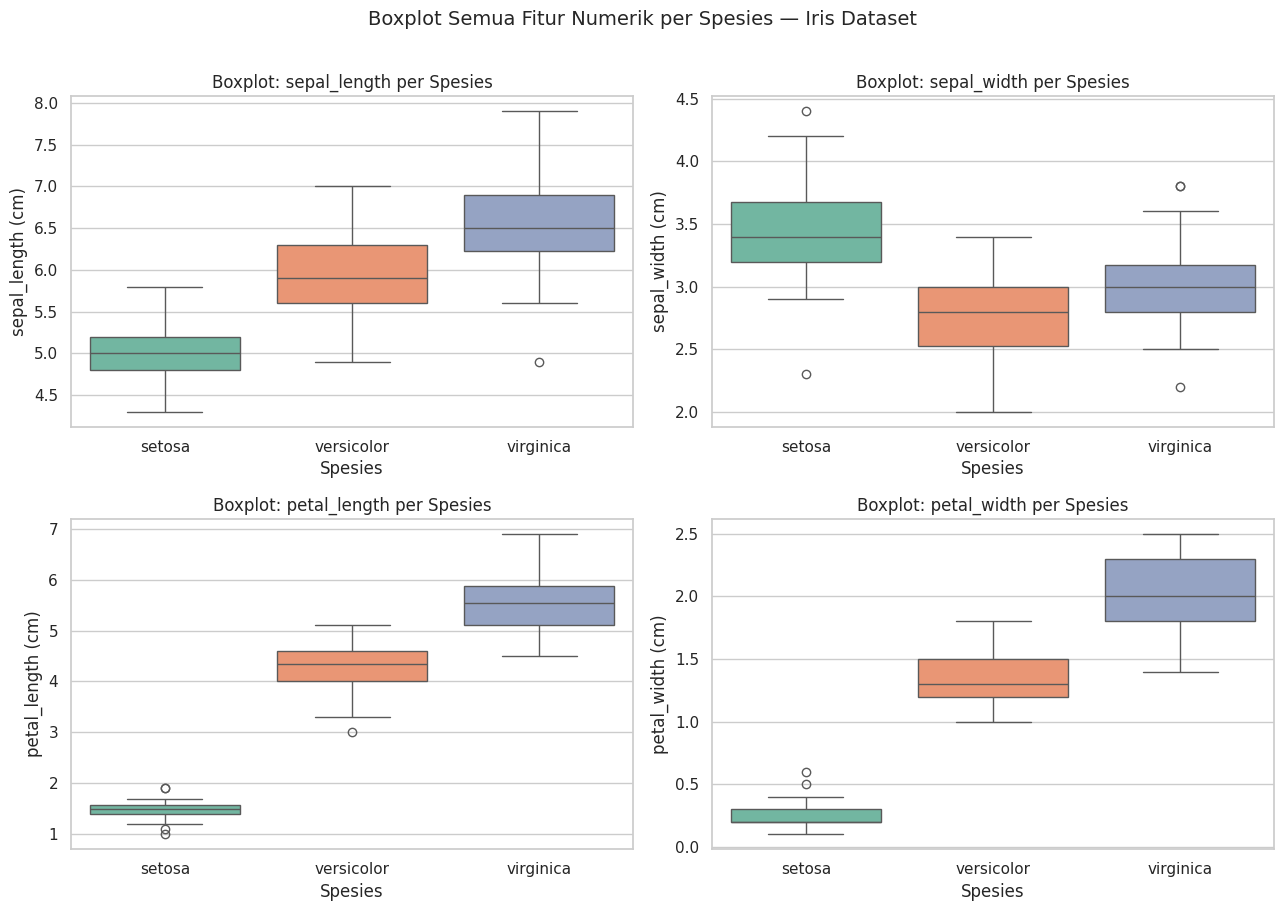

In [12]:
# Langkah 4b: Boxplot semua fitur numerik
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, col_name in enumerate(numerik_cols):
    sns.boxplot(data=df, x='species', y=col_name,
                palette='Set2', ax=axes[i])
    axes[i].set_title(f'Boxplot: {col_name} per Spesies')
    axes[i].set_xlabel('Spesies')
    axes[i].set_ylabel(f'{col_name} (cm)')

plt.suptitle('Boxplot Semua Fitur Numerik per Spesies — Iris Dataset',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('boxplot_all_features.png', dpi=150)
plt.show()

In [13]:
# Langkah 4c: Statistik per spesies untuk petal_length
print('=== STATISTIK PETAL_LENGTH PER SPESIES ===')
stats_per_species = df.groupby('species')['petal_length'].agg(
    ['mean', 'median', 'std', 'min', 'max']
).round(3)
print(stats_per_species)
print()
print('Kesimpulan:')
print('  Petal_length terbesar  → Virginica')
print('  Petal_length terkecil  → Setosa')
print('  Paling tersebar (std)  → Virginica')

=== STATISTIK PETAL_LENGTH PER SPESIES ===
             mean  median    std  min  max
species                                   
setosa      1.462    1.50  0.174  1.0  1.9
versicolor  4.260    4.35  0.470  3.0  5.1
virginica   5.552    5.55  0.552  4.5  6.9

Kesimpulan:
  Petal_length terbesar  → Virginica
  Petal_length terkecil  → Setosa
  Paling tersebar (std)  → Virginica


**Narasi Interpretasi Langkah 4:**

- **Setosa** memiliki `petal_length` terkecil dengan sebaran sangat sempit (std rendah), menunjukkan spesies ini sangat konsisten dan mudah dipisahkan.
- **Versicolor** berada di tengah dengan beberapa outlier terdeteksi.
- **Virginica** memiliki nilai tertinggi dengan sebaran paling luas, menandakan variabilitas terbesar di antara ketiga spesies.
- Violin plot mengungkap bahwa distribusi Versicolor cenderung lebih simetris, sementara Virginica sedikit miring kiri.

---
## Langkah 5 — Matriks Korelasi Pearson

**Koefisien korelasi Pearson (r)** mengukur kekuatan dan arah hubungan **linear** antara dua variabel numerik. Nilainya berkisar −1 hingga +1.

| Nilai |r| | Interpretasi |
|-----------|-------------|
| 0.90–1.00 | Sangat kuat |
| 0.70–0.89 | Kuat |
| 0.50–0.69 | Sedang |
| 0.30–0.49 | Lemah |
| 0.00–0.29 | Sangat lemah |

> ⚠️ **Korelasi ≠ Kausalitas!** Dua variabel berkorelasi bisa jadi karena sama-sama dipengaruhi variabel ketiga (confounding variable).

In [14]:
# Langkah 5a: Hitung matriks korelasi Pearson
corr = df.drop('species', axis=1).corr(method='pearson')

print('=== MATRIKS KORELASI PEARSON ===')
print(corr.round(3))

=== MATRIKS KORELASI PEARSON ===
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000


In [15]:
# Langkah 5b: Identifikasi pasangan korelasi tertinggi dan terendah
# Masking diagonal atas agar tidak duplikat
mask_triu = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask_triu)

max_pair = corr_masked.abs().stack().idxmax()
min_pair = corr_masked.abs().stack().idxmin()

print(f'Korelasi TERTINGGI : {max_pair} = {corr.loc[max_pair]:.4f}')
print(f'Korelasi TERENDAH  : {min_pair} = {corr.loc[min_pair]:.4f}')

Korelasi TERTINGGI : ('petal_width', 'petal_length') = 0.9629
Korelasi TERENDAH  : ('sepal_width', 'sepal_length') = -0.1176


In [16]:
# Langkah 5c: Uji korelasi Pearson dan Spearman dengan scipy
from scipy import stats

x = df['petal_length']
y = df['petal_width']

r_pearson,  p_pearson  = stats.pearsonr(x, y)
r_spearman, p_spearman = stats.spearmanr(x, y)

print('=== UJI KORELASI: petal_length vs petal_width ===')
print(f'Pearson  r = {r_pearson:.4f}  (p-value = {p_pearson:.2e})')
print(f'Spearman ρ = {r_spearman:.4f}  (p-value = {p_spearman:.2e})')
print()
print('Interpretasi:')
print(f'  Kekuatan korelasi : {"Sangat kuat" if abs(r_pearson) >= 0.9 else "Kuat" if abs(r_pearson) >= 0.7 else "Sedang"}')
print(f'  Arah              : {"Positif" if r_pearson > 0 else "Negatif"}')
print(f'  Signifikansi (α=0.05): {"Signifikan" if p_pearson < 0.05 else "Tidak signifikan"}')

=== UJI KORELASI: petal_length vs petal_width ===
Pearson  r = 0.9629  (p-value = 4.68e-86)
Spearman ρ = 0.9377  (p-value = 8.16e-70)

Interpretasi:
  Kekuatan korelasi : Sangat kuat
  Arah              : Positif
  Signifikansi (α=0.05): Signifikan


---
## Langkah 6 — Scatter Plot & Heatmap Korelasi

**Scatter Plot** memvisualisasikan hubungan antara dua variabel sebagai titik-titik dalam ruang 2D. Garis regresi membantu mengidentifikasi tren linear.

**Heatmap Korelasi** memvisualisasikan seluruh matriks korelasi sekaligus menggunakan skala warna:
- **Merah** → korelasi positif kuat
- **Biru** → korelasi negatif kuat
- **Putih / terang** → lemah atau tidak berkorelasi

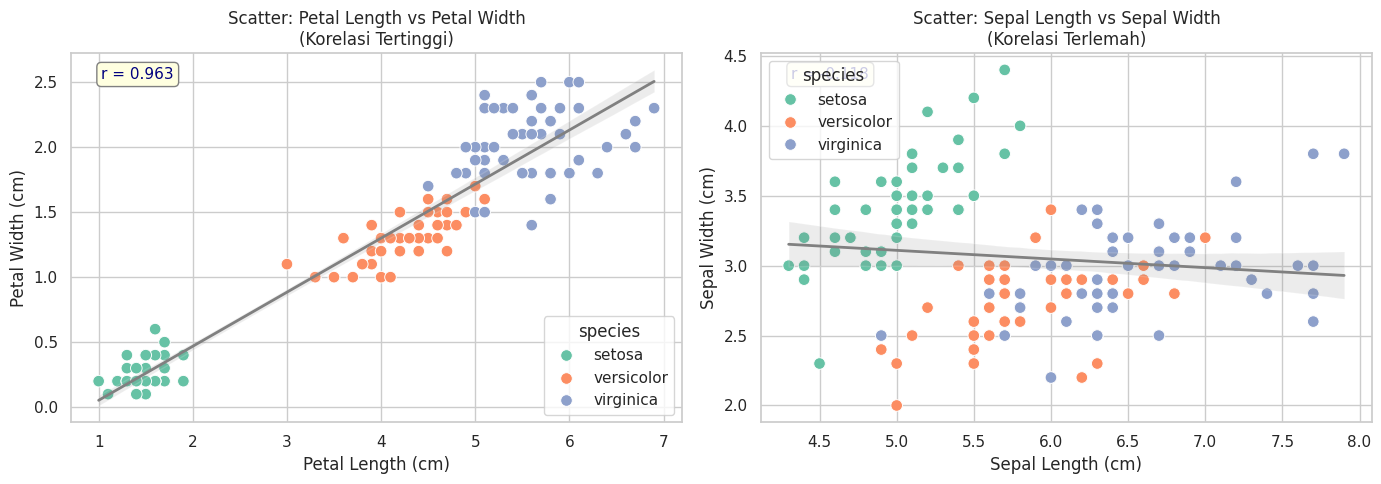

In [17]:
# Langkah 6a: Scatter plot pasangan berkorelasi tertinggi (petal_length vs petal_width)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter per spesies + garis regresi
sns.scatterplot(data=df, x='petal_length', y='petal_width',
                hue='species', palette='Set2', s=70, ax=axes[0])
sns.regplot(data=df, x='petal_length', y='petal_width',
            scatter=False, color='gray', line_kws={'lw': 2}, ax=axes[0])
axes[0].set_title('Scatter: Petal Length vs Petal Width\n(Korelasi Tertinggi)',
                  fontsize=12)
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')

# Tambahkan anotasi nilai r
r, _ = stats.pearsonr(df['petal_length'], df['petal_width'])
axes[0].text(0.05, 0.93, f'r = {r:.3f}',
             transform=axes[0].transAxes,
             fontsize=11, color='navy',
             bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='gray'))

# Scatter sepal_length vs sepal_width (korelasi terlemah)
sns.scatterplot(data=df, x='sepal_length', y='sepal_width',
                hue='species', palette='Set2', s=70, ax=axes[1])
sns.regplot(data=df, x='sepal_length', y='sepal_width',
            scatter=False, color='gray', line_kws={'lw': 2}, ax=axes[1])
axes[1].set_title('Scatter: Sepal Length vs Sepal Width\n(Korelasi Terlemah)',
                  fontsize=12)
axes[1].set_xlabel('Sepal Length (cm)')
axes[1].set_ylabel('Sepal Width (cm)')

r2, _ = stats.pearsonr(df['sepal_length'], df['sepal_width'])
axes[1].text(0.05, 0.93, f'r = {r2:.3f}',
             transform=axes[1].transAxes,
             fontsize=11, color='navy',
             bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='gray'))

plt.tight_layout()
plt.savefig('scatter_petal_sepal.png', dpi=150)
plt.show()

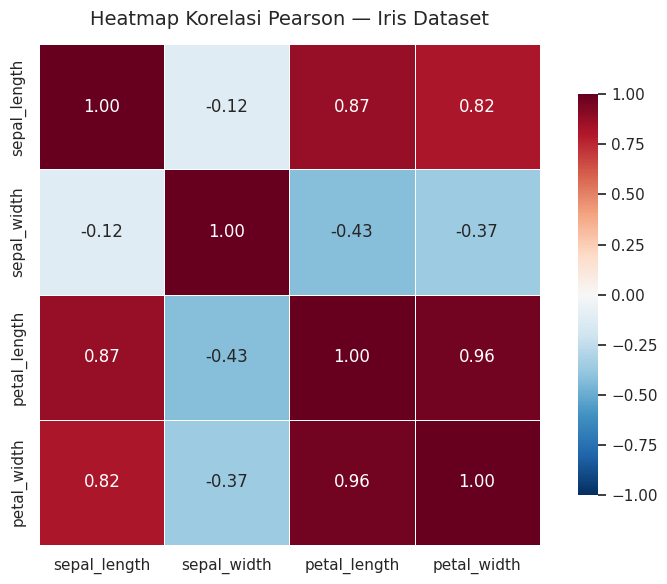

In [18]:
# Langkah 6b: Heatmap Korelasi Pearson
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'shrink': 0.8}
)

ax.set_title('Heatmap Korelasi Pearson — Iris Dataset',
             fontsize=14, pad=14)
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150)
plt.show()

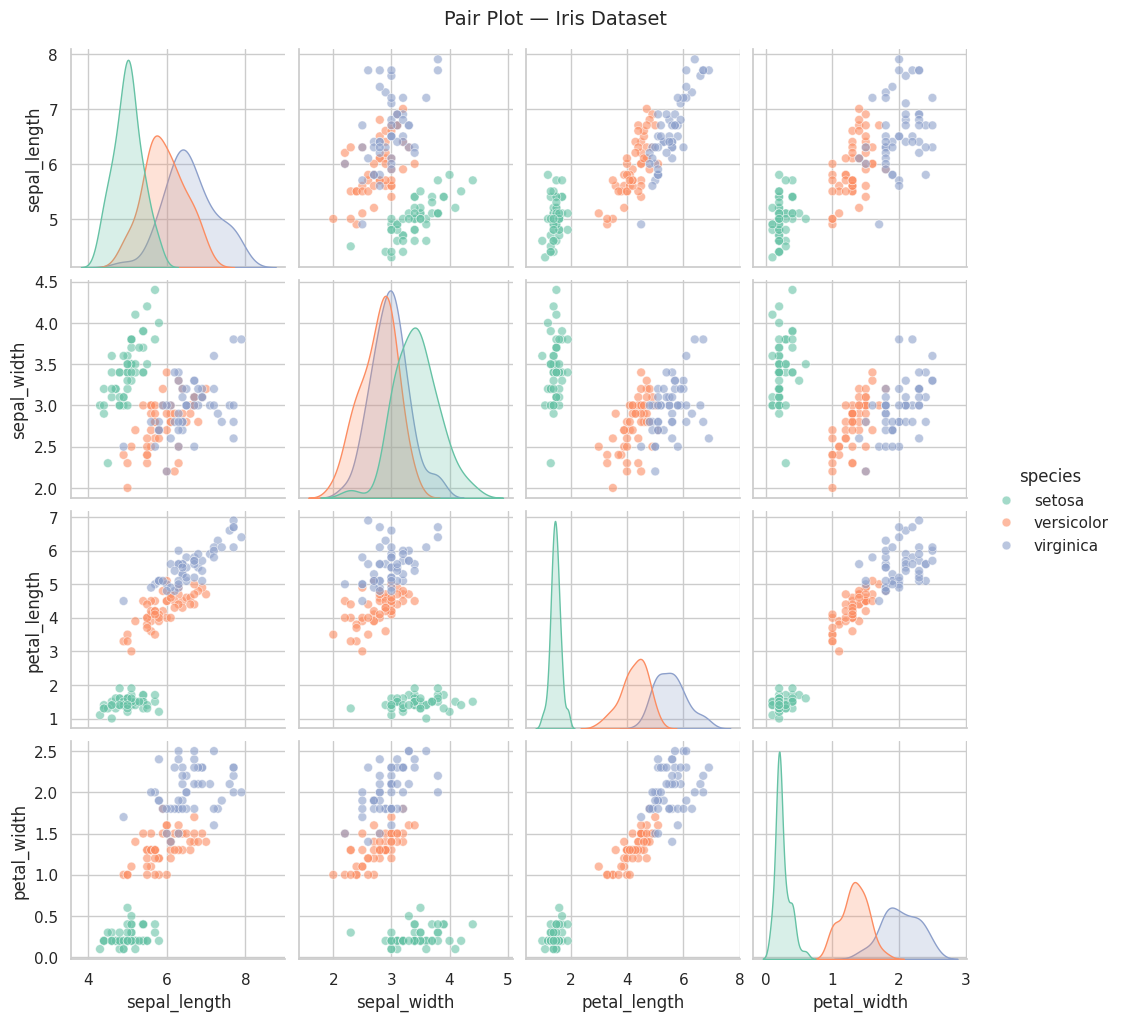

In [19]:
# Langkah 6c: Pair Plot — semua kombinasi pasangan fitur
g = sns.pairplot(df, hue='species', palette='Set2',
                 plot_kws={'alpha': 0.6, 's': 40},
                 diag_kind='kde')
g.figure.suptitle('Pair Plot — Iris Dataset', y=1.02, fontsize=14)
plt.savefig('pairplot_iris.png', dpi=120)
plt.show()

**Narasi Interpretasi Langkah 6:**

Dari heatmap dan scatter plot, dapat disimpulkan:

1. **petal_length – petal_width** memiliki korelasi Pearson r ≈ 0.96 (sangat kuat positif). Semakin panjang mahkota, semakin lebar pula mahkota tersebut.
2. **sepal_length – petal_length** dan **sepal_length – petal_width** juga berkorelasi kuat (r ≈ 0.87 dan r ≈ 0.82).
3. **sepal_width** berkorelasi sangat lemah bahkan negatif dengan semua fitur lainnya (r ≈ −0.12 hingga −0.37), artinya lebar kelopak bukan prediktor yang baik untuk fitur-fitur lain.
4. Pair plot mengkonfirmasi bahwa **Setosa** sangat mudah dipisahkan dari dua spesies lainnya terutama berdasarkan fitur petal, sedangkan Versicolor dan Virginica memiliki tumpang tindih yang lebih banyak.

> **Catatan:** Korelasi yang kuat antara petal_length dan petal_width dapat menimbulkan **multikolinearitas** dalam model regresi linear, sehingga perlu dipertimbangkan saat memilih fitur untuk pemodelan machine learning.

---
## Ringkasan Hasil Analisis

| Langkah | Teknik | Temuan Utama |
|---------|--------|--------------|
| 1 | Load & Inspect | 150 baris × 5 kolom, 3 spesies seimbang (50 masing-masing), tanpa missing values |
| 2 | Statistik Deskriptif | petal_width paling right-skewed (skew ≈ −0.1 s/d 0.15 untuk sepal, lebih tinggi untuk petal) |
| 3 | Histogram + KDE | sepal berdistribusi mendekati normal; petal memiliki distribusi bimodal (setosa terpisah jelas) |
| 4 | Boxplot per Spesies | Setosa memiliki petal terkecil & paling konsisten; Virginica terbesar & paling tersebar |
| 5 | Korelasi Pearson | Korelasi tertinggi: petal_length–petal_width (r ≈ 0.96); terendah: sepal_length–sepal_width (r ≈ −0.12) |
| 6 | Scatter + Heatmap | Fitur petal jauh lebih diskriminatif antar spesies dibanding fitur sepal |

## Refleksi Singkat

Pertemuan 4 memberikan fondasi matematis yang kuat dalam analisis data. Statistika deskriptif bukan sekadar menghitung angka — ia adalah proses *mengenal* data sebelum memodelkannya. Dari eksplorasi dataset Iris, saya memahami bahwa visualisasi (histogram, boxplot, scatter plot, heatmap) adalah jembatan penting antara angka statistik dan intuisi. Temuan bahwa fitur `petal_length` dan `petal_width` sangat berkorelasi (r ≈ 0.96) dan sangat diskriminatif antar spesies menjadi petunjuk berharga untuk pemilihan fitur pada model klasifikasi di pertemuan-pertemuan berikutnya.

---
**Keterbatasan & Pertanyaan:** Korelasi Pearson hanya mengukur hubungan linear — hubungan non-linear tidak terdeteksi. Pertanyaan yang muncul: apakah korelasi tinggi antara `petal_length` dan `petal_width` (r ≈ 0.96) akan menyebabkan masalah multikolinearitas yang signifikan pada model regresi? Bagaimana cara memilih antara Pearson dan Spearman secara sistematis?